In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Customer_Purchase_Prediction.csv")

print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (500, 13)


,Customer_ID,Age,Gender,Annual_Income,Customer_Segment,Previous_Purchases,Website_Visits,Pages_Viewed,Time_on_Website_Min,Emails_Opened,Cart_Additions,Days_Since_Last_Purchase,Purchase
0,C001,19.0,Female,112737.0,Regular,2.0,4.0,6.0,14.1,4.0,5.0,66.0,0
1,C002,24.0,Male,45636.0,Regular,3.0,12.0,9.0,17.0,2.0,2.0,56.0,0
2,C003,44.0,Male,84833.0,Regular,2.0,12.0,4.0,15.7,5.0,2.0,173.0,0
3,C004,31.0,Male,138787.0,Regular,6.0,12.0,6.0,16.7,3.0,1.0,52.0,1
4,C005,31.0,Male,38301.0,Loyal,7.0,7.0,6.0,16.5,5.0,2.0,64.0,0


## 1. Dataset Description

The dataset contains 500 customer records and 13 columns. It includes customer demographic information, annual income, purchasing history, and website activity.

The target variable is `Purchase`, where 0 represents no purchase and 1 represents a purchase.

The dataset contains both numerical and categorical features. `Customer_ID` is an identifier and will be removed before model training.

In [59]:
print("Dataset Information")
print("=" * 50)

df.info()

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer_ID               500 non-null    object 
 1   Age                       496 non-null    float64
 2   Gender                    497 non-null    object 
 3   Annual_Income             497 non-null    float64
 4   Customer_Segment          497 non-null    object 
 5   Previous_Purchases        497 non-null    float64
 6   Website_Visits            497 non-null    float64
 7   Pages_Viewed              497 non-null    float64
 8   Time_on_Website_Min       497 non-null    float64
 9   Emails_Opened             498 non-null    float64
 10  Cart_Additions            499 non-null    float64
 11  Days_Since_Last_Purchase  499 non-null    float64
 12  Purchase                  500 non-null    int64  
dtypes: float64(9), int64(1), object(3)
memory usa

### Initial Data Quality Check

The dataset contains 500 records and 13 columns. The `df.info()` output shows both numerical and categorical features with some missing values. The missing-value analysis identifies 29 missing values across the dataset. Duplicate rows are also checked before preprocessing.

In [4]:
print("Duplicate Rows:", df.duplicated().sum())

Column Names:
['Customer_ID', 'Age', 'Gender', 'Annual_Income', 'Customer_Segment', 'Previous_Purchases', 'Website_Visits', 'Pages_Viewed', 'Time_on_Website_Min', 'Emails_Opened', 'Cart_Additions', 'Days_Since_Last_Purchase', 'Purchase']


In [5]:
print("Missing Values in Each Column:")
print(df.isnull().sum())

print("\nTotal Missing Values:", df.isnull().sum().sum())

Missing Values in Each Column:
Customer_ID                 0
Age                         4
Gender                      3
Annual_Income               3
Customer_Segment            3
Previous_Purchases          3
Website_Visits              3
Pages_Viewed                3
Time_on_Website_Min         3
Emails_Opened               2
Cart_Additions              1
Days_Since_Last_Purchase    1
Purchase                    0
dtype: int64

Total Missing Values: 29


In [6]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 13


In [7]:
print("Purchase Class Distribution:")
print(df["Purchase"].value_counts())

print("\nPurchase Percentage:")
print(df["Purchase"].value_counts(normalize=True) * 100)

Purchase Class Distribution:
Purchase
0    334
1    166
Name: count, dtype: int64

Purchase Percentage:
Purchase
0    66.8
1    33.2
Name: proportion, dtype: float64


In [8]:
print("Shape Before Removing Duplicates:", df.shape)
print("Duplicate Rows:", df.duplicated().sum())

df = df.drop_duplicates()

print("\nShape After Removing Duplicates:", df.shape)
print("Duplicate Rows After Removal:", df.duplicated().sum())

Shape Before Removing Duplicates: (500, 13)
Duplicate Rows: 13

Shape After Removing Duplicates: (487, 13)
Duplicate Rows After Removal: 0


In [9]:
print("Missing Values Before Treatment:")
print(df.isnull().sum())

print("\nTotal Missing Values:",
      df.isnull().sum().sum())

Missing Values Before Treatment:
Customer_ID                 0
Age                         3
Gender                      3
Annual_Income               3
Customer_Segment            3
Previous_Purchases          3
Website_Visits              3
Pages_Viewed                3
Time_on_Website_Min         3
Emails_Opened               2
Cart_Additions              1
Days_Since_Last_Purchase    1
Purchase                    0
dtype: int64

Total Missing Values: 28


In [11]:
numerical_columns = df.select_dtypes(include='number').columns.tolist()
categorical_columns = df.select_dtypes(include='object').columns.tolist()

print("Numerical Columns:")
print(numerical_columns)

print("\nCategorical Columns:")
print(categorical_columns)

Numerical Columns:
['Age', 'Annual_Income', 'Previous_Purchases', 'Website_Visits', 'Pages_Viewed', 'Time_on_Website_Min', 'Emails_Opened', 'Cart_Additions', 'Days_Since_Last_Purchase', 'Purchase']

Categorical Columns:
['Customer_ID', 'Gender', 'Customer_Segment']


In [12]:
df = df.drop("Customer_ID", axis=1)

print("Shape After Removing Customer_ID:", df.shape)
print("\nRemaining Columns:")
print(df.columns.tolist())

Shape After Removing Customer_ID: (487, 12)

Remaining Columns:
['Age', 'Gender', 'Annual_Income', 'Customer_Segment', 'Previous_Purchases', 'Website_Visits', 'Pages_Viewed', 'Time_on_Website_Min', 'Emails_Opened', 'Cart_Additions', 'Days_Since_Last_Purchase', 'Purchase']


In [13]:
numerical_columns = df.select_dtypes(include='number').columns.tolist()
categorical_columns = df.select_dtypes(include='object').columns.tolist()

# Remove target from numerical feature list
numerical_features = [col for col in numerical_columns if col != "Purchase"]

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_columns)

Numerical Features:
['Age', 'Annual_Income', 'Previous_Purchases', 'Website_Visits', 'Pages_Viewed', 'Time_on_Website_Min', 'Emails_Opened', 'Cart_Additions', 'Days_Since_Last_Purchase']

Categorical Features:
['Gender', 'Customer_Segment']


In [14]:
# Handle missing values in numerical features

for column in numerical_features:
    if df[column].isnull().sum() > 0:
        median_value = df[column].median()
        df[column] = df[column].fillna(median_value)
        print(column, "-> Median used:", median_value)


# Handle missing values in categorical features

for column in categorical_columns:
    if df[column].isnull().sum() > 0:
        mode_value = df[column].mode()[0]
        df[column] = df[column].fillna(mode_value)
        print(column, "-> Mode used:", mode_value)

Age -> Median used: 39.0
Annual_Income -> Median used: 82887.5
Previous_Purchases -> Median used: 5.0
Website_Visits -> Median used: 10.0
Pages_Viewed -> Median used: 6.0
Time_on_Website_Min -> Median used: 11.9
Emails_Opened -> Median used: 4.0
Cart_Additions -> Median used: 2.0
Days_Since_Last_Purchase -> Median used: 90.0
Gender -> Mode used: Female
Customer_Segment -> Mode used: Regular


In [15]:
print("Missing Values After Treatment:")
print(df.isnull().sum())

print("\nTotal Missing Values After Treatment:",
      df.isnull().sum().sum())

Missing Values After Treatment:
Age                         0
Gender                      0
Annual_Income               0
Customer_Segment            0
Previous_Purchases          0
Website_Visits              0
Pages_Viewed                0
Time_on_Website_Min         0
Emails_Opened               0
Cart_Additions              0
Days_Since_Last_Purchase    0
Purchase                    0
dtype: int64

Total Missing Values After Treatment: 0


In [16]:
print("Descriptive Statistics")
print("=" * 50)

display(df.describe())

Descriptive Statistics


,Age,Annual_Income,Previous_Purchases,Website_Visits,Pages_Viewed,Time_on_Website_Min,Emails_Opened,Cart_Additions,Days_Since_Last_Purchase,Purchase
count,487.000000,487.000000,487.000000,487.000000,487.000000,487.000000,487.000000,487.000000,487.000000,487.000000
mean,39.036961,83309.947639,5.094456,10.106776,5.891170,12.078850,4.043121,2.039014,89.254620,0.334702
std,12.226711,37394.472665,2.372534,3.251605,2.366272,4.769004,2.062847,1.423104,53.042657,0.472372
min,18.000000,20261.000000,0.000000,3.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,28.000000,51417.000000,3.000000,8.000000,4.000000,8.950000,2.000000,1.000000,41.500000,0.000000
50%,39.000000,82887.500000,5.000000,10.000000,6.000000,11.900000,4.000000,2.000000,90.000000,0.000000
75%,50.000000,116369.500000,7.000000,12.000000,7.000000,15.500000,5.000000,3.000000,135.500000,1.000000
max,60.000000,149904.000000,14.000000,21.000000,17.000000,25.700000,12.000000,9.000000,180.000000,1.000000


In [17]:
print("Categorical Data Summary")
print("=" * 50)

display(df.describe(include='object'))

Categorical Data Summary


,Gender,Customer_Segment
count,487,487
unique,2,3
top,Female,Regular
freq,246,345


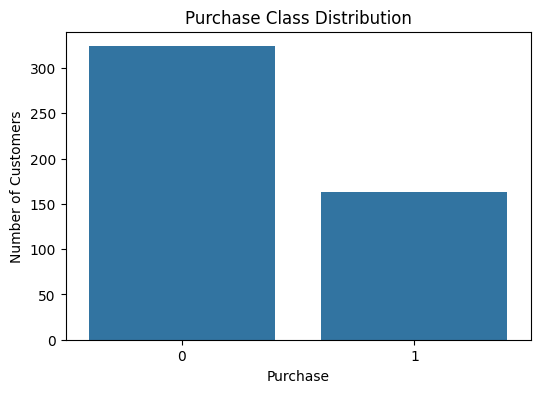

In [18]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Purchase")

plt.title("Purchase Class Distribution")
plt.xlabel("Purchase")
plt.ylabel("Number of Customers")

plt.show()

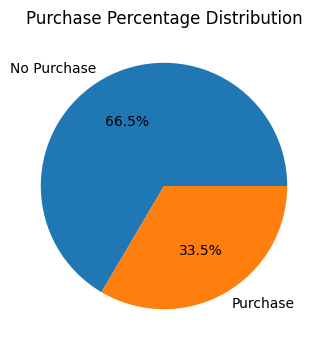

In [19]:
purchase_counts = df["Purchase"].value_counts()

plt.figure(figsize=(6, 4))

plt.pie(
    purchase_counts,
    labels=["No Purchase", "Purchase"],
    autopct="%1.1f%%"
)

plt.title("Purchase Percentage Distribution")
plt.show()

In [ ]:
# Observation

#The purchase class distribution shows that 66.5% of the customers did not make a purchase, while 33.5% made a purchase. Therefore, the target variable is somewhat imbalanced, with more customers belonging to the non-purchase class.

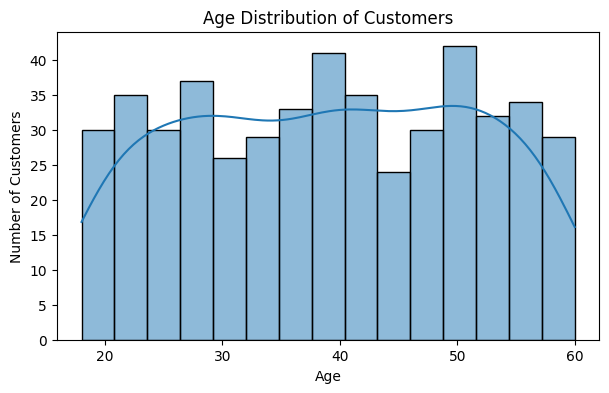

In [20]:
plt.figure(figsize=(7, 4))

sns.histplot(data=df, x="Age", bins=15, kde=True)

plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

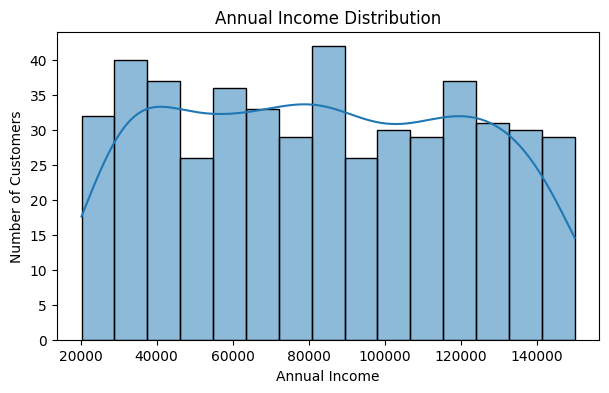

In [21]:
plt.figure(figsize=(7, 4))

sns.histplot(data=df, x="Annual_Income", bins=15, kde=True)

plt.title("Annual Income Distribution")
plt.xlabel("Annual Income")
plt.ylabel("Number of Customers")

plt.show()

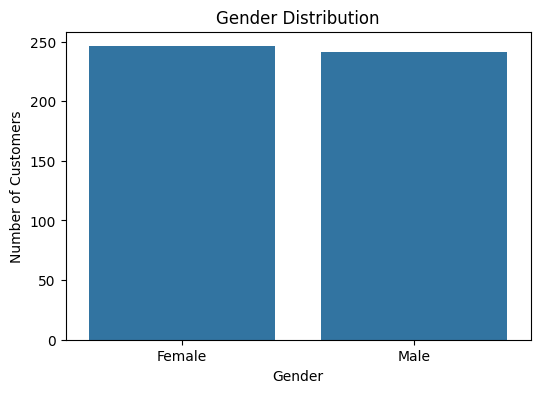

In [22]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Gender")

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

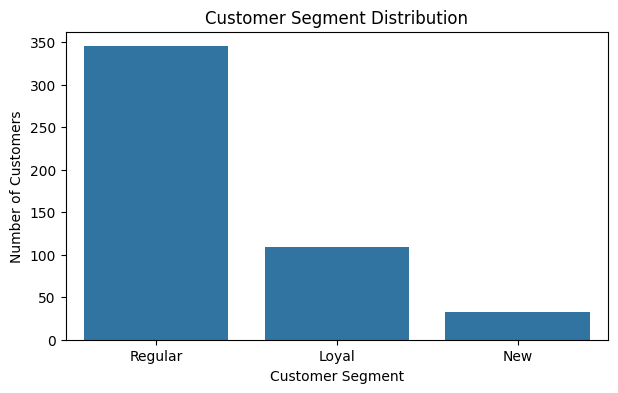

In [23]:
plt.figure(figsize=(7, 4))

sns.countplot(data=df, x="Customer_Segment")

plt.title("Customer Segment Distribution")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.show()

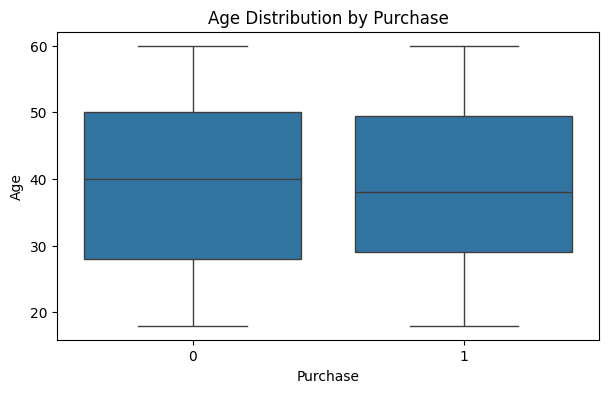

In [24]:
plt.figure(figsize=(7, 4))

sns.boxplot(data=df, x="Purchase", y="Age")

plt.title("Age Distribution by Purchase")
plt.xlabel("Purchase")
plt.ylabel("Age")

plt.show()

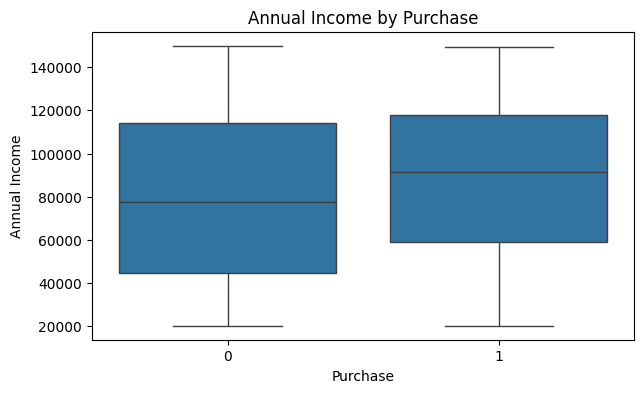

In [25]:
plt.figure(figsize=(7, 4))

sns.boxplot(data=df, x="Purchase", y="Annual_Income")

plt.title("Annual Income by Purchase")
plt.xlabel("Purchase")
plt.ylabel("Annual Income")

plt.show()

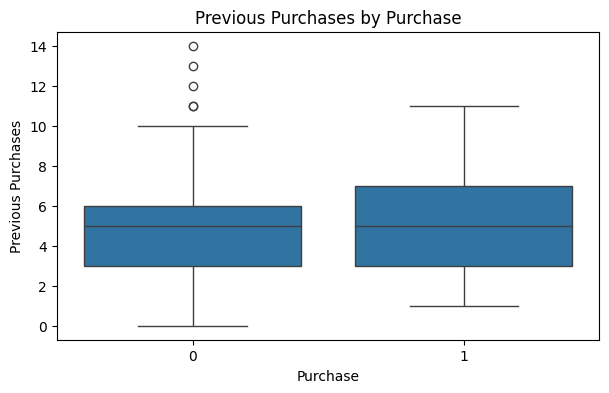

In [26]:
plt.figure(figsize=(7, 4))

sns.boxplot(data=df, x="Purchase", y="Previous_Purchases")

plt.title("Previous Purchases by Purchase")
plt.xlabel("Purchase")
plt.ylabel("Previous Purchases")

plt.show()

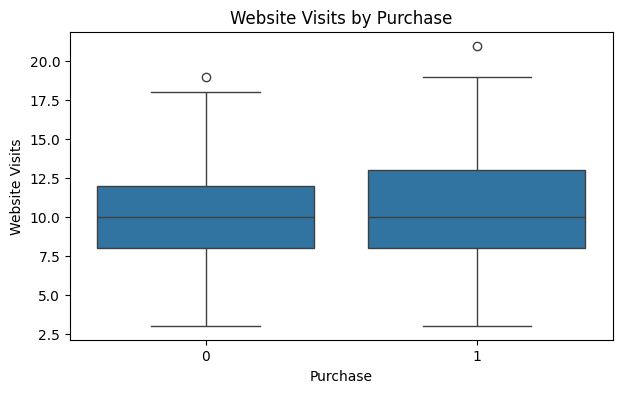

In [27]:
plt.figure(figsize=(7, 4))

sns.boxplot(data=df, x="Purchase", y="Website_Visits")

plt.title("Website Visits by Purchase")
plt.xlabel("Purchase")
plt.ylabel("Website Visits")

plt.show()

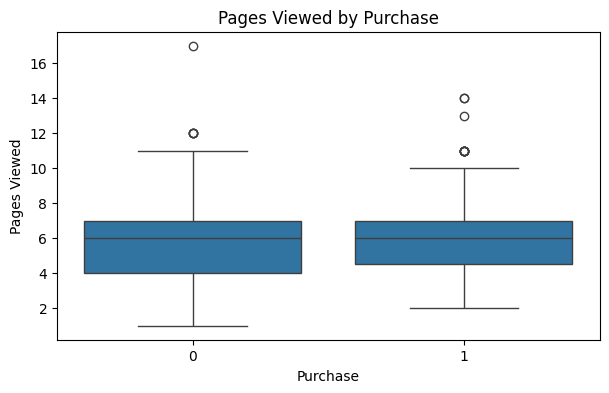

In [28]:
plt.figure(figsize=(7, 4))

sns.boxplot(data=df, x="Purchase", y="Pages_Viewed")

plt.title("Pages Viewed by Purchase")
plt.xlabel("Purchase")
plt.ylabel("Pages Viewed")

plt.show()

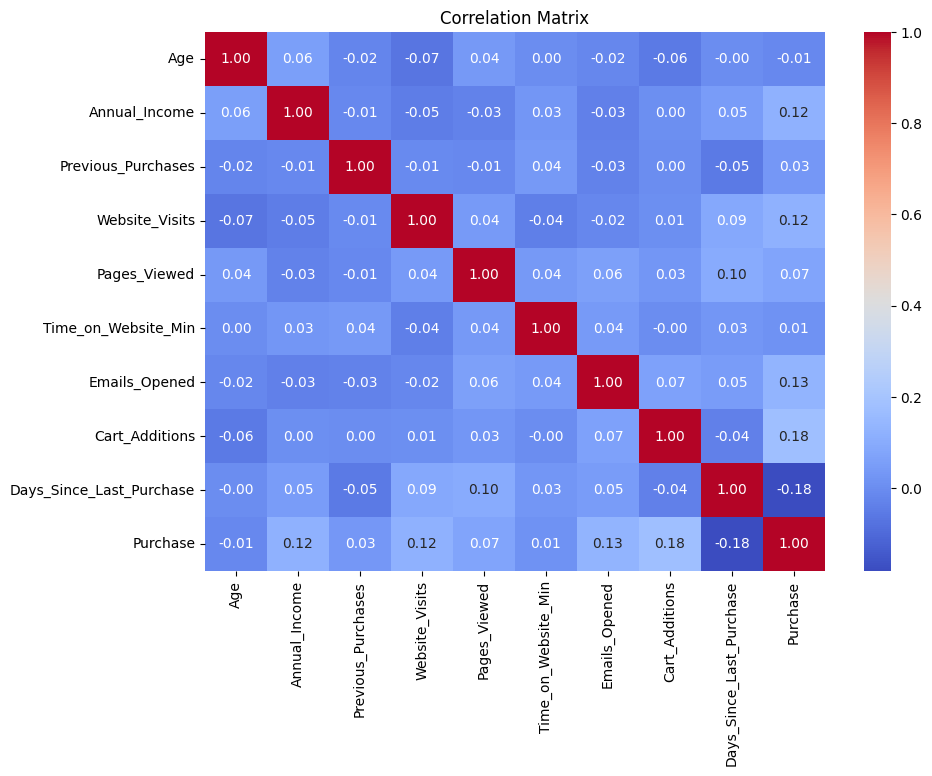

In [29]:
plt.figure(figsize=(10, 7))

correlation = df.corr(numeric_only=True)

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

### Correlation Analysis

The correlation matrix was used to examine the relationships between numerical features and the target variable `Purchase`. The correlations with `Purchase` are relatively weak, indicating that no single numerical feature has a strong linear relationship with the target.

In [30]:
print("Features used for modelling:")
print(df.drop("Purchase", axis=1).columns.tolist())

print("\nTarget variable:")
print("Purchase")

Features used for modelling:
['Age', 'Gender', 'Annual_Income', 'Customer_Segment', 'Previous_Purchases', 'Website_Visits', 'Pages_Viewed', 'Time_on_Website_Min', 'Emails_Opened', 'Cart_Additions', 'Days_Since_Last_Purchase']

Target variable:
Purchase


## 4. Model Preparation and Preprocessing

The cleaned dataset was divided into training and testing sets using an 80:20 stratified split. Numerical features were standardized and categorical features were one-hot encoded using a preprocessing pipeline.

The preprocessing pipeline is fitted as part of the training process so that information from the test dataset is not used during preprocessing, helping to prevent data leakage.

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Load the original raw dataset again
model_df = pd.read_csv("Customer_Purchase_Prediction.csv")

# Remove duplicate rows
model_df = model_df.drop_duplicates()

# Remove Customer_ID
model_df = model_df.drop("Customer_ID", axis=1)

# Separate features and target
X = model_df.drop("Purchase", axis=1)
y = model_df["Purchase"]

print("Dataset shape for modelling:", model_df.shape)
print("Features:", X.columns.tolist())
print("Target: Purchase")

Dataset shape for modelling: (487, 12)
Features: ['Age', 'Gender', 'Annual_Income', 'Customer_Segment', 'Previous_Purchases', 'Website_Visits', 'Pages_Viewed', 'Time_on_Website_Min', 'Emails_Opened', 'Cart_Additions', 'Days_Since_Last_Purchase']
Target: Purchase


In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 389
Testing samples: 98


In [34]:
numeric_features = [
    "Age",
    "Annual_Income",
    "Previous_Purchases",
    "Website_Visits",
    "Pages_Viewed",
    "Time_on_Website_Min",
    "Emails_Opened",
    "Cart_Additions",
    "Days_Since_Last_Purchase"
]

categorical_features = [
    "Gender",
    "Customer_Segment"
]

In [35]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

## 5. Logistic Regression

Logistic Regression was implemented as a baseline classification model for predicting customer purchase behaviour.

In [36]:
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

logistic_model.fit(X_train, y_train)

y_pred_log = logistic_model.predict(X_test)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [37]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy_log = accuracy_score(y_test, y_pred_log)
precision_log = precision_score(y_test, y_pred_log)
recall_log = recall_score(y_test, y_pred_log)
f1_log = f1_score(y_test, y_pred_log)

print("Logistic Regression Results")
print("=" * 40)
print("Accuracy :", round(accuracy_log, 4))
print("Precision:", round(precision_log, 4))
print("Recall   :", round(recall_log, 4))
print("F1-Score :", round(f1_log, 4))

Logistic Regression Results
Accuracy : 0.6939
Precision: 0.5882
Recall   : 0.303
F1-Score : 0.4


In [38]:
from sklearn.metrics import classification_report

print("Logistic Regression Classification Report")
print("=" * 50)

print(classification_report(y_test, y_pred_log))

Logistic Regression Classification Report
              precision    recall  f1-score   support

           0       0.72      0.89      0.79        65
           1       0.59      0.30      0.40        33

    accuracy                           0.69        98
   macro avg       0.65      0.60      0.60        98
weighted avg       0.67      0.69      0.66        98



Logistic Regression Confusion Matrix:
[[58  7]
 [23 10]]


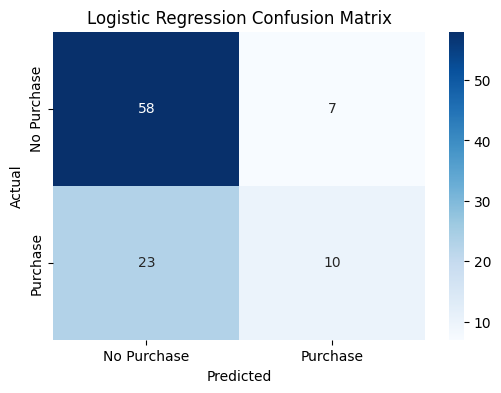

In [39]:
from sklearn.metrics import confusion_matrix

cm_log = confusion_matrix(y_test, y_pred_log)

print("Logistic Regression Confusion Matrix:")
print(cm_log)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_log,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Purchase", "Purchase"],
    yticklabels=["No Purchase", "Purchase"]
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [40]:
from sklearn.metrics import roc_auc_score, roc_curve

# Probability of the positive class
y_prob_log = logistic_model.predict_proba(X_test)[:, 1]

# ROC-AUC
roc_auc_log = roc_auc_score(y_test, y_prob_log)

print("Logistic Regression ROC-AUC:", round(roc_auc_log, 4))

Logistic Regression ROC-AUC: 0.6755


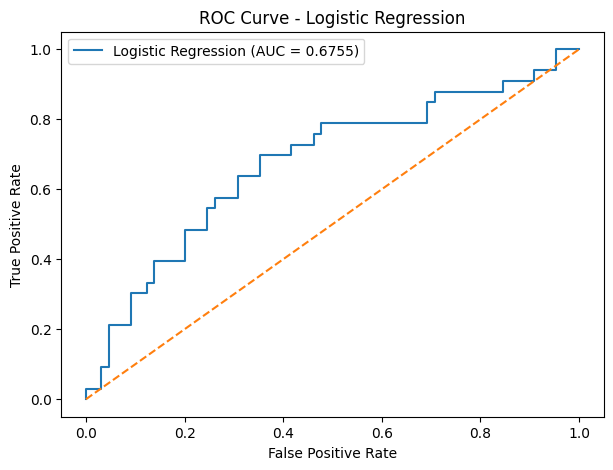

In [41]:
plt.figure(figsize=(7, 5))

fpr_log, tpr_log, thresholds_log = roc_curve(y_test, y_prob_log)

plt.plot(
    fpr_log,
    tpr_log,
    label=f"Logistic Regression (AUC = {roc_auc_log:.4f})"
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()

plt.show()

## 6. Random Forest

Random Forest was implemented as a second classification model to compare its performance with Logistic Regression.

In [43]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

random_forest_model.fit(X_train, y_train)

y_pred_rf = random_forest_model.predict(X_test)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [44]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Random Forest Results")
print("=" * 40)
print("Accuracy :", round(accuracy_rf, 4))
print("Precision:", round(precision_rf, 4))
print("Recall   :", round(recall_rf, 4))
print("F1-Score :", round(f1_rf, 4))

Random Forest Results
Accuracy : 0.6837
Precision: 0.5833
Recall   : 0.2121
F1-Score : 0.3111


In [45]:
print("Random Forest Classification Report")
print("=" * 50)

print(classification_report(y_test, y_pred_rf))

Random Forest Classification Report
              precision    recall  f1-score   support

           0       0.70      0.92      0.79        65
           1       0.58      0.21      0.31        33

    accuracy                           0.68        98
   macro avg       0.64      0.57      0.55        98
weighted avg       0.66      0.68      0.63        98



Random Forest Confusion Matrix:
[[60  5]
 [26  7]]


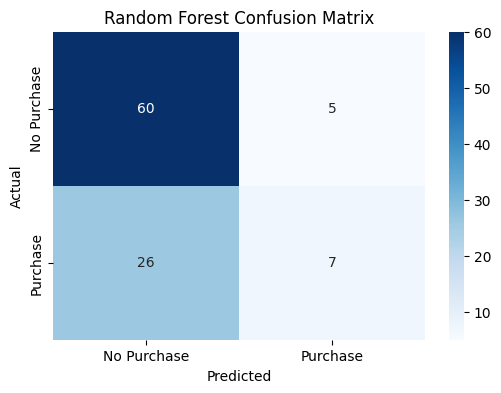

In [46]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

print("Random Forest Confusion Matrix:")
print(cm_rf)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Purchase", "Purchase"],
    yticklabels=["No Purchase", "Purchase"]
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [47]:
# Probability of the positive class
y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

# ROC-AUC
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest ROC-AUC:", round(roc_auc_rf, 4))

Random Forest ROC-AUC: 0.6823


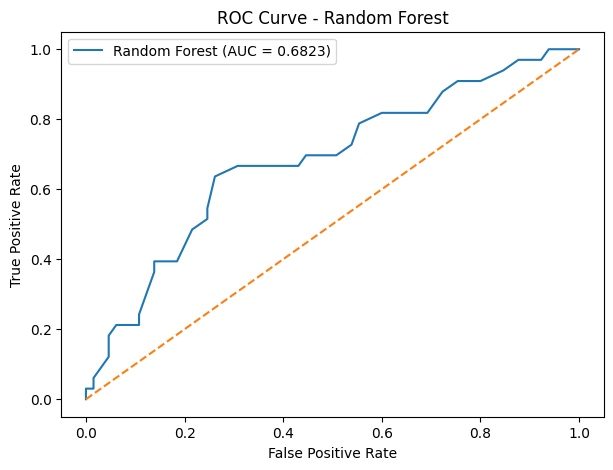

In [48]:
plt.figure(figsize=(7, 5))

fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_prob_rf)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {roc_auc_rf:.4f})"
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()

plt.show()

In [49]:
# Get feature names after preprocessing
feature_names = random_forest_model.named_steps["preprocessor"].get_feature_names_out()

# Get Random Forest feature importance
importances = random_forest_model.named_steps["classifier"].feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

display(feature_importance)

,Feature,Importance
8,num__Days_Since_Last_Purchase,0.167712
1,num__Annual_Income,0.140899
5,num__Time_on_Website_Min,0.109004
3,num__Website_Visits,0.102802
0,num__Age,0.102425
6,num__Emails_Opened,0.086127
4,num__Pages_Viewed,0.082056
2,num__Previous_Purchases,0.069725
7,num__Cart_Additions,0.065696
10,cat__Gender_Male,0.019902


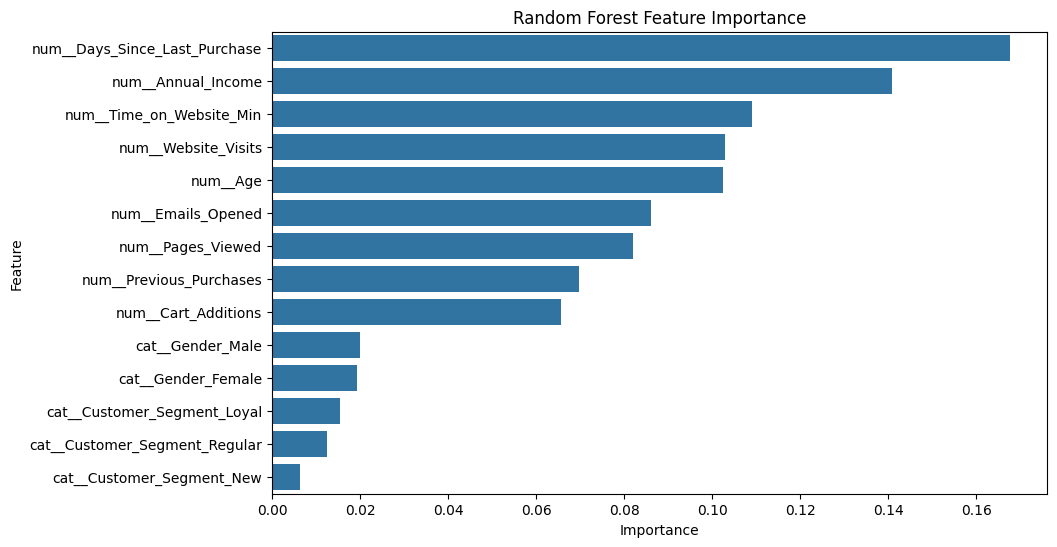

In [50]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

### Random Forest Feature Importance

The feature-importance results show that `Days_Since_Last_Purchase`, `Annual_Income`, `Time_on_Website_Min`, `Website_Visits`, and `Age` have relatively higher importance in the fitted Random Forest model. These values indicate the contribution of each feature to the model's predictions and do not imply a causal relationship.

## 7. Hyperparameter Tuning

Grid Search with 5-fold cross-validation was used to evaluate different Random Forest hyperparameter combinations. The parameters considered include the number of trees, maximum tree depth, and minimum samples required for splitting.

In [51]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "classifier__n_estimators": [50, 100, 150],
    "classifier__max_depth": [None, 5, 10],
    "classifier__min_samples_split": [2, 5]
}

grid_search = GridSearchCV(
    estimator=random_forest_model,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation Accuracy:",
      round(grid_search.best_score_, 4))

Best Parameters:
{'classifier__max_depth': 10, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 50}

Best Cross-Validation Accuracy: 0.6917


In [52]:
best_rf_model = grid_search.best_estimator_

y_pred_tuned = best_rf_model.predict(X_test)

accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
precision_tuned = precision_score(y_test, y_pred_tuned)
recall_tuned = recall_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned)

print("Tuned Random Forest Results")
print("=" * 40)
print("Accuracy :", round(accuracy_tuned, 4))
print("Precision:", round(precision_tuned, 4))
print("Recall   :", round(recall_tuned, 4))
print("F1-Score :", round(f1_tuned, 4))

Tuned Random Forest Results
Accuracy : 0.6531
Precision: 0.4667
Recall   : 0.2121
F1-Score : 0.2917


In [55]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Tuned Random Forest"
    ],
    "Accuracy": [
        accuracy_log,
        accuracy_rf,
        accuracy_tuned
    ],
    "Precision": [
        precision_log,
        precision_rf,
        precision_tuned
    ],
    "Recall": [
        recall_log,
        recall_rf,
        recall_tuned
    ],
    "F1-Score": [
        f1_log,
        f1_rf,
        f1_tuned
    ],
    "ROC-AUC": [
        roc_auc_log,
        roc_auc_rf,
        roc_auc_tuned
    ]
})

display(comparison.round(4))

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.6939,0.5882,0.3030,0.4000,0.6755
1,Random Forest,0.6837,0.5833,0.2121,0.3111,0.6823
2,Tuned Random Forest,0.6531,0.4667,0.2121,0.2917,0.6135


## 8. Model Comparison

The three implemented models were compared using accuracy, precision, recall, F1-score, and ROC-AUC. The comparison helps evaluate their performance on the same test dataset.

In [72]:
new_customer = pd.DataFrame({
    "Age": [35],
    "Gender": ["Male"],
    "Annual_Income": [80000],
    "Customer_Segment": ["Regular"],
    "Previous_Purchases": [5],
    "Website_Visits": [10],
    "Pages_Viewed": [6],
    "Time_on_Website_Min": [10],
    "Emails_Opened": [4],
    "Cart_Additions": [2],
    "Days_Since_Last_Purchase": [6]
})

display(new_customer)

,Age,Gender,Annual_Income,Customer_Segment,Previous_Purchases,Website_Visits,Pages_Viewed,Time_on_Website_Min,Emails_Opened,Cart_Additions,Days_Since_Last_Purchase
0,35,Male,80000,Regular,5,10,6,10,4,2,6


In [73]:
prediction = logistic_model.predict(new_customer)
probability = logistic_model.predict_proba(new_customer)[0][1]

print("Predicted Purchase:", prediction[0])
print("Purchase Probability:", round(probability, 4))

Predicted Purchase: 1
Purchase Probability: 0.5415


## 9. Final Prediction / Demonstration

The trained Logistic Regression model is used to demonstrate prediction on a new customer record that was not included in the training or test data.

## 10. Results and Discussion

Three classification models were implemented and evaluated: Logistic Regression, Random Forest, and Tuned Random Forest.

Logistic Regression achieved an accuracy of 69.39%, precision of 58.82%, recall of 30.30%, F1-score of 40.00%, and ROC-AUC of 0.6755.

Random Forest achieved an accuracy of 68.37%, precision of 58.33%, recall of 21.21%, F1-score of 31.11%, and ROC-AUC of 0.6823.

The tuned Random Forest achieved a cross-validation accuracy of 69.17%, but its test accuracy was 65.31%, with a precision of 46.67%, recall of 21.21%, F1-score of 29.17%, and ROC-AUC of 0.6135.

The results show that the models identified non-purchase customers more effectively than purchase customers. The relatively lower recall for the purchase class indicates that some actual purchasers were classified as non-purchasers.

The Random Forest feature-importance analysis showed that `Days_Since_Last_Purchase`, `Annual_Income`, `Time_on_Website_Min`, `Website_Visits`, and `Age` had relatively higher importance in the fitted model.

Overall, the experiments demonstrate the differences in performance between the baseline, ensemble, and tuned models on the given customer purchase dataset.

## 10. Results and Discussion

Three classification models were implemented and evaluated: Logistic Regression, Random Forest, and Tuned Random Forest.

Logistic Regression achieved an accuracy of 69.39%, precision of 58.82%, recall of 30.30%, F1-score of 40.00%, and ROC-AUC of 0.6755.

Random Forest achieved an accuracy of 68.37%, precision of 58.33%, recall of 21.21%, F1-score of 31.11%, and ROC-AUC of 0.6823.

The tuned Random Forest achieved a cross-validation accuracy of 69.17%, but its test accuracy was 65.31%, with a precision of 46.67%, recall of 21.21%, F1-score of 29.17%, and ROC-AUC of 0.6135.

The results show that the models identified non-purchase customers more effectively than purchase customers. The relatively lower recall for the purchase class indicates that some actual purchasers were classified as non-purchasers.

The Random Forest feature-importance analysis showed that `Days_Since_Last_Purchase`, `Annual_Income`, `Time_on_Website_Min`, `Website_Visits`, and `Age` had relatively higher importance in the fitted model.

Overall, the experiments demonstrate the differences in performance between the baseline, ensemble, and tuned models on the given customer purchase dataset.